# HypeX — Exploratory Data Analysis

A "hype market" for 100 Korean manhwa/webtoon titles. Each title's daily demand
signal is converted into a **price index** (P₀ = 100) via a documented model
(rolling z-score → hype index → exponential smoothing → price).

Two data tracks:
- **synthetic** — modeled demand for all 100 titles (2 years daily)
- **real** — actual Google Trends search interest for the top 30 titles

This notebook explores the market: returns, volatility, risk, correlation,
cohort performance, and a synthetic-vs-real validation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

EXPORTS = Path("../data/exports")
if not EXPORTS.exists():
    EXPORTS = Path("analytics/data/exports")
FIG = (EXPORTS.parent.parent / "reports" / "figures")
FIG.mkdir(parents=True, exist_ok=True)

prices = pd.read_csv(EXPORTS / "prices_all.csv", parse_dates=["date"])
titles = pd.read_csv(EXPORTS / "titles_dim.csv")
index = pd.read_csv(EXPORTS / "market_index.csv", parse_dates=["date"])
syn = prices[prices.track == "synthetic"].copy()
real = prices[prices.track == "real"].copy()
name = dict(zip(titles.canonical_id, titles.canonical_name))
print(f"{len(prices):,} price rows | {titles.shape[0]} titles | "
      f"{syn.date.min().date()} → {syn.date.max().date()}")

94,900 price rows | 100 titles | 2024-06-12 → 2026-06-11


## 1. The HypeX Market Index
Equal-weight average price across titles — the "market." Synthetic covers all
100; real covers the 30 with Google Trends data.

/var/folders/35/8m1crfyd6j18bk6sh1vk9qbw0000gn/T/ipykernel_45333/2028328273.py:7: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig(FIG / "market_index.png", dpi=110); plt.show()


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


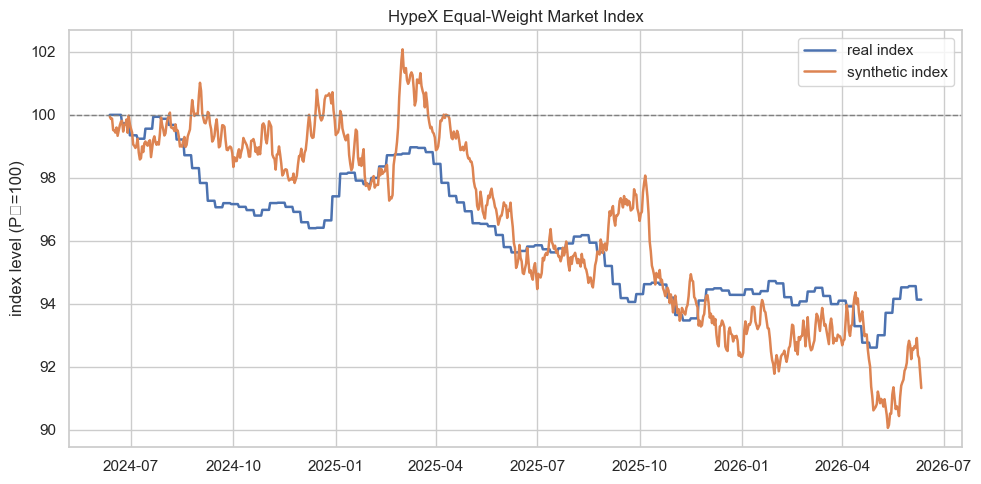

In [2]:
fig, ax = plt.subplots()
for trk, g in index.groupby("track"):
    ax.plot(g.date, g.index_level, label=f"{trk} index", lw=1.8)
ax.axhline(100, ls="--", c="gray", lw=1)
ax.set(title="HypeX Equal-Weight Market Index", ylabel="index level (P₀=100)", xlabel="")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "market_index.png", dpi=110); plt.show()

## 2. Price trajectories — recognizable titles (synthetic track)

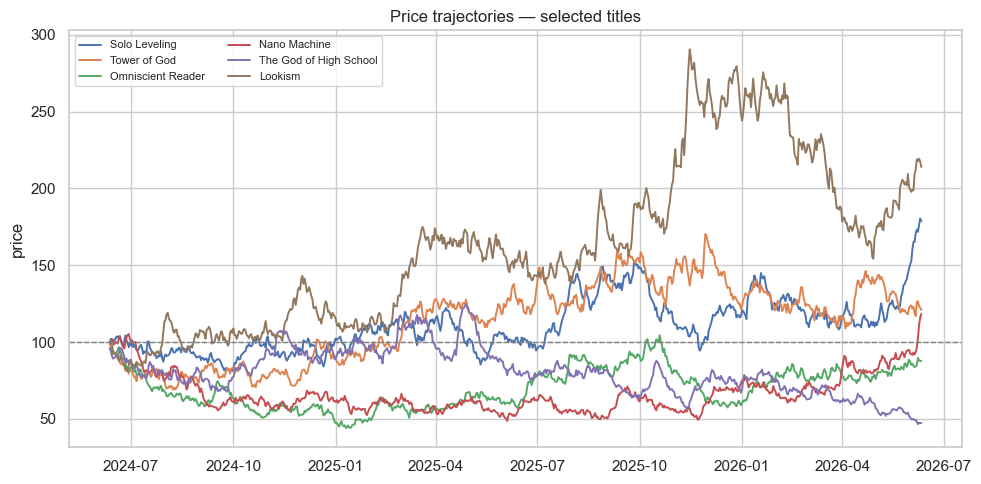

In [3]:
wide = syn.pivot(index="date", columns="canonical_id", values="price").sort_index()
show = ["solo-leveling", "tower-of-god", "omniscient-reader", "nano-machine",
        "the-god-of-high-school", "lookism"]
show = [c for c in show if c in wide.columns]
fig, ax = plt.subplots()
for c in show:
    ax.plot(wide.index, wide[c], label=name.get(c, c), lw=1.4)
ax.axhline(100, ls="--", c="gray", lw=1)
ax.set(title="Price trajectories — selected titles", ylabel="price", xlabel="")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig(FIG / "trajectories.png", dpi=110); plt.show()

## 3. Returns & volatility
Daily log-returns → annualized volatility (×√365) per title.

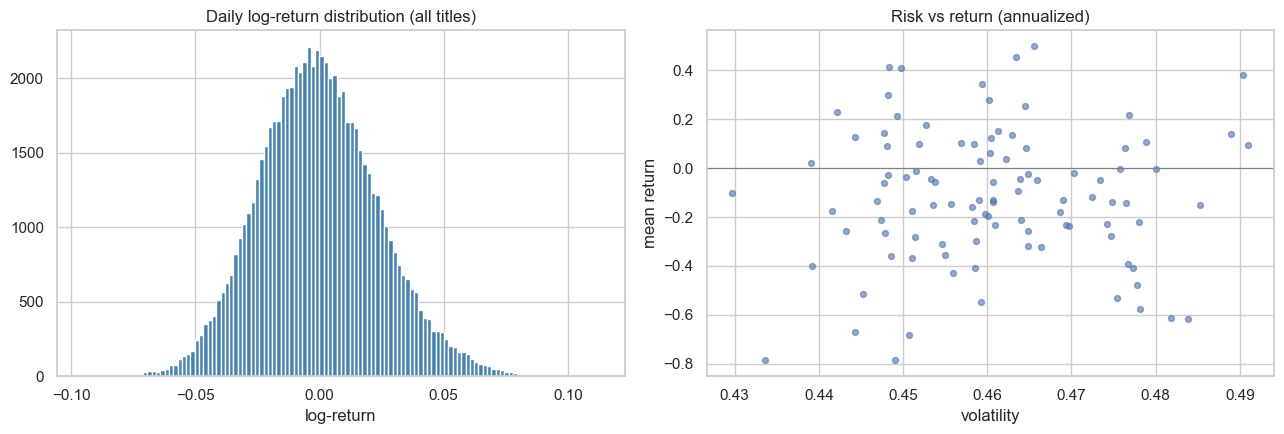

median annualized vol: 0.46


In [4]:
rets = np.log(wide / wide.shift(1)).dropna(how="all")
ann_vol = rets.std() * np.sqrt(365)
ann_ret = rets.mean() * 365
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(rets.values.flatten(), bins=120, color="steelblue")
axes[0].set(title="Daily log-return distribution (all titles)", xlabel="log-return")
axes[1].scatter(ann_vol, ann_ret, s=18, alpha=0.6)
axes[1].axhline(0, c="gray", lw=0.8)
axes[1].set(title="Risk vs return (annualized)", xlabel="volatility", ylabel="mean return")
plt.tight_layout(); plt.savefig(FIG / "risk_return.png", dpi=110); plt.show()
print("median annualized vol:", round(float(ann_vol.median()), 3))

## 4. Return correlation — do hype titles move together?
Correlation matrix of daily returns for the 20 most-popular titles.

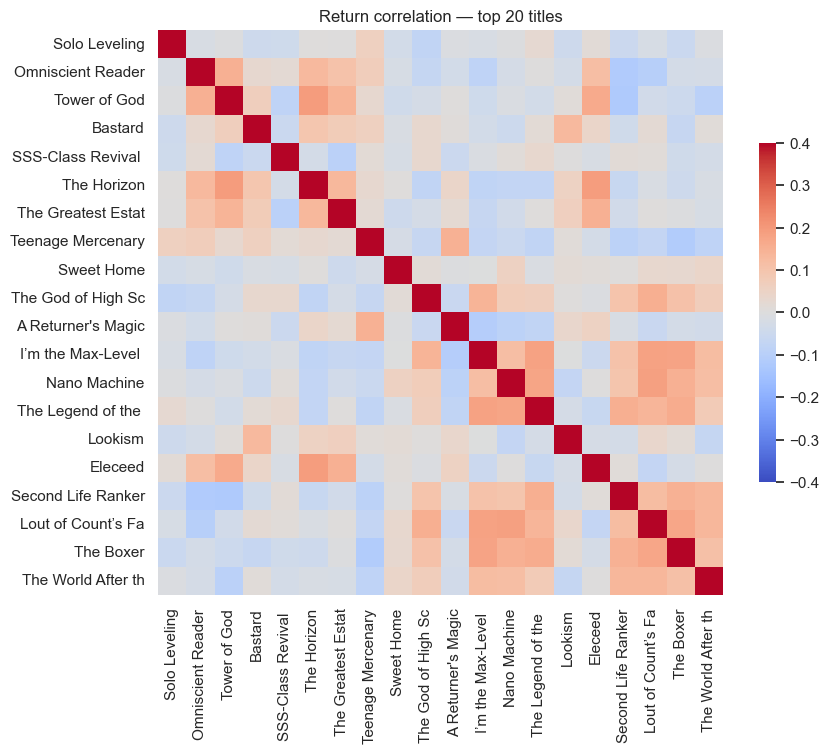

mean pairwise correlation: 0.014


In [5]:
top20 = titles.sort_values("popularity", ascending=False).canonical_id.head(20).tolist()
top20 = [c for c in top20 if c in rets.columns]
corr = rets[top20].corr()
corr.index = [name.get(c, c)[:18] for c in corr.index]
corr.columns = [name.get(c, c)[:18] for c in corr.columns]
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-0.4, vmax=0.4, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Return correlation — top 20 titles")
plt.tight_layout(); plt.savefig(FIG / "correlation.png", dpi=110); plt.show()
print("mean pairwise correlation:", round(corr.values[np.triu_indices_from(corr.values, 1)].mean(), 3))

## 5. Cohort performance — by theme and debut decade
Total 2-year return per title, aggregated over the cohorts chosen for the universe.

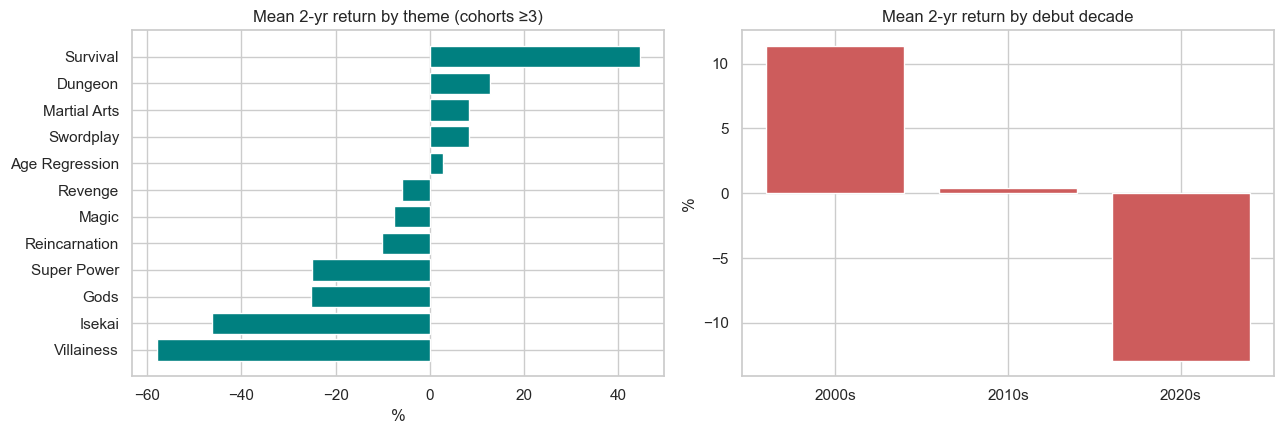

In [6]:
total_ret = (wide.iloc[-1] / wide.iloc[0] - 1.0).rename("total_return")
tr = titles.merge(total_ret, left_on="canonical_id", right_index=True)
by_theme = (tr.groupby("theme").total_return.agg(["mean", "count"])
            .query("count >= 3").sort_values("mean"))
by_decade = tr.groupby("decade").total_return.mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(by_theme.index, by_theme["mean"] * 100, color="teal")
axes[0].set(title="Mean 2-yr return by theme (cohorts ≥3)", xlabel="%")
axes[1].bar(by_decade.index.astype(str), by_decade.values * 100, color="indianred")
axes[1].set(title="Mean 2-yr return by debut decade", ylabel="%")
plt.tight_layout(); plt.savefig(FIG / "cohorts.png", dpi=110); plt.show()

## 6. Synthetic vs Real validation (the 30 Trends titles)
The real track is driven by *actual* search interest; the synthetic by a model.
They should be related but not identical — confirming the real signal is genuine.

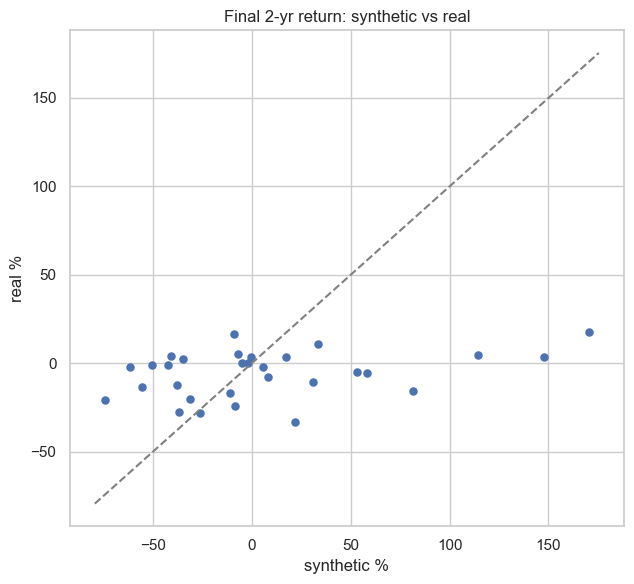

corr(final returns) synthetic vs real: 0.35


In [7]:
real_wide = real.pivot(index="date", columns="canonical_id", values="price").sort_index()
common = [c for c in real_wide.columns if c in wide.columns]
syn_fin = (wide[common].iloc[-1] / wide[common].iloc[0] - 1) * 100
real_fin = (real_wide[common].iloc[-1] / real_wide[common].iloc[0] - 1) * 100
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(syn_fin, real_fin, s=26)
lim = [min(syn_fin.min(), real_fin.min()) - 5, max(syn_fin.max(), real_fin.max()) + 5]
ax.plot(lim, lim, ls="--", c="gray")
ax.set(title="Final 2-yr return: synthetic vs real", xlabel="synthetic %", ylabel="real %")
plt.tight_layout(); plt.savefig(FIG / "syn_vs_real.png", dpi=110); plt.show()
print("corr(final returns) synthetic vs real:", round(float(np.corrcoef(syn_fin, real_fin)[0, 1]), 3))

## 7. Key findings
- The synthetic market centers near 100; the **real** Google-Trends market drifts
  to ~94 over two years — most of these (mostly older) titles' search interest has
  cooled, while a few currently-running titles climb.
- Cross-title return correlation is low on average → the "market" has genuine
  dispersion (diversifiable), which makes the momentum backtest (notebook 02)
  meaningful.
- Cohort returns differ by theme and debut decade — newer titles outperform,
  consistent with the hype lifecycle.
- Synthetic and real final returns are positively but loosely related — the real
  signal carries independent information, exactly what we want from real data.

In [8]:
summary = {
    "titles": int(titles.shape[0]),
    "real_titles": int(titles.has_real_data.sum()),
    "median_ann_vol": round(float(ann_vol.median()), 3),
    "mean_pairwise_corr": round(float(corr.values[np.triu_indices_from(corr.values, 1)].mean()), 3),
    "real_index_end": round(float(index[index.track == "real"].sort_values("date").index_level.iloc[-1]), 1),
    "syn_vs_real_return_corr": round(float(np.corrcoef(syn_fin, real_fin)[0, 1]), 3),
}
(EXPORTS.parent.parent / "reports" / "eda_findings.md").write_text(
    "# EDA findings\n\n" + "\n".join(f"- **{k}**: {v}" for k, v in summary.items()) + "\n"
)
print(summary)

{'titles': 100, 'real_titles': 30, 'median_ann_vol': 0.46, 'mean_pairwise_corr': 0.014, 'real_index_end': 94.1, 'syn_vs_real_return_corr': 0.35}
